Author: Thomas Joyce

Class: ASTR 400B - Galaxies and Cosmology

Description: Workbook documenting Homework 6

--------------------------------------------------------------------------------------------------------------------------------

In [1]:
### Importations ###
# Numpy and Astropy
import numpy as np
# Plotting
import matplotlib.pyplot as plt
# External (must be in same directory as Homework6)
from CenterOfMass import CenterOfMass

In [2]:
def OrbitCOM(galaxy, start, end, n):
        ''' 
        Description: Designs a txt file in a 7 column format, 
        tracking the time, position, and velocity of a galaxies center of mass
            
        Inputs:
            - galaxy: string name of galxy (ex: "MW")
            - start: the interger number corresponding to the first snapshot to be read in
            - end: the interget number correponding to the last snapshot to be read in
            - n: an interger number corresponding to the amout of intervals over which the COM will be returned
            
        '''
        # Defining relevant COM parameters #
        Delta = 0.1
        VolDec = 2
        if galaxy == 'M33':
            VolDec = 4
        
        
        # Defining Output Filename #
        OutputName = 'Orbit_' + galaxy + '.txt'
        
        snap_ids = np.array(np.arange(start, end, n)) # array of snap designations to be read in
        
        # Check to end function if equal divisions of n are not achieved #
        if abs(end - start) % n != 0:
            print('Interval is incompatible!!!')
            print('Function Ending ...')
            return
        
        orbit = np.zeros([len(snap_ids), 7]) # defining output list to store values
        
        # For loop to iterate through snap shots #
        for i, snap_id in enumerate(snap_ids):
            # Determining File Name #
            ilbl = '000' + str(snap_id) # adding snap number to the value '000'
            ilbl = ilbl[-3:] # only the last 3 digits being used
            
            Filename = '%s_'%(galaxy) + ilbl + '.txt' # reconstructing filename
            
            # Creating Center of Mass Object #
            gal_COM = CenterOfMass(FileName, 2) # Center of mass object using disk particles
            
            # Computing center of mass for object #
            gal_P = gal_COM.COM_P(Delta, VolDec)
            gal_V = gal_COM.COM_V(gal_P[0], gal_P[1], gal_P[2])
            
            Time = gal_COM.time / 1000 # Time in Gyr of Snapshot
            
            # Storing values to orbit array #
            orbit[i][0] = Time.value # time is the first index (column)
            
            orbit[i][1] = gal_P[0].value # x position is the second index (column)
            orbit[i][2] = gal_P[1].value # y position is the third index (column)
            orbit[i][3] = gal_P[2].value # z position is the fourth index (column)
            
            orbit[i][4] = gal_V[0].value # x velocity is the fifth index (column)
            orbit[i][5] = gal_V[1].value # y velocity is the sixth index (column)
            orbit[i][6] = gal_V[2].value # z velocity is the seventh index (column)
            
            # Print statmeent for code running visibility #
            print('Iteration: ' + str(i) + ' / ' + str(len(snap_ids) - 1))
            
        # Saving to txt file #
        np.savetxt(OutputName, orbit, fmt = "%11.3f"*7, comments = '#', 
                   header = "{:10s}{:11s}{:11s}{:11s}{:11s}{:11s}{:11s}".format('t', 'x', 'y', 'z', 'vx', 'vy', 'vz'))
### END OrbitCOM
    
            

In [3]:
# Generating Orbit txt Files #

# Milky Way Orbits #
#OrbitCOM('MW', 0, 800, 5)

# M31 Orbits #
#OrbitCOM('M31', 0, 800, 5)

# M33 Orbits #
#OrbitCOM('M33', 0, 800, 5)

### NOTE ###
''' Don't bother running these lines, I left all the data txt file sout of 
the repository to prevent a mass upload to git hub, I do have the resulting Orbit
txt files with each iteration saved in the directory '''

" Don't bother running these lines, I left all the data txt file sout of \nthe repository to prevent a mass upload to git hub, I do have the resulting Orbit\ntxt files with each iteration saved in the directory "

In [4]:
def ReadOrbitFile(FileName):
    ''' 
    Description: reads orbit txt file generated from OrbitCOM and saves the data
    into variables Time, Gal_pos, and Gal_vec 
    
    Inputs:
        - FileName: File name to be read in (string)
        
    Returns:
        - Time: a list of time values in Gyr (NON Astropy Quantity)
        - Gal_Pos: an array of COM position vectors for the galaxy in kpc, the data
        is formatted as Gal_Pos = [ [COM X positions], [COM Y positions], [COM Z positions] ]
        (NON Astropy Quantity)
        - Gal_Vec: an array of COM velocity vectors for the galaxy in km/s, the data
        is formatted as Gal_Vec = [ [COM X velocity], [COM Y velocity], [COM Z velocity] ]
        (NON Astropy Quantity)'''
    data = np.genfromtxt(FileName, dtype = None, names = True, skip_header = 0) # data array creation
    
    Time = data['t']
    Gal_Pos = [ data['x'], data['y'], data['z'] ]
    Gal_Vec = [ data['vx'], data['vy'], data['vz'] ]
    
    return Time, Gal_Pos, Gal_Vec
### END ReadOrbitFile

In [5]:
def RelativeSeperation(Gal1, Gal2):
    ''' 
    Description: Determines the relative seperation of a state vector for Galaxy 1 (Gal1)
    and Galaxy 2 (Gal2). This can be done with position (giving the relative position seperation) and
    with velocity (giving ht relative velocity between the two)
    
    Inputs:
        - Gal1: State vector for galaxy 1, list with indeces [x_component, y_component, z_component]
        - Gal2: State vector for galaxy 2, list with indeces [x_component, y_component, z_component]
        
    Returns:
        - SeperationMagnitude: Magnitude of the difference between the two state vectors
    '''
    
    # Computing X Seperation #
    X_sep = Gal2[0] - Gal1[0]
    
    # Computing Y Seperation #
    Y_sep = Gal2[1] - Gal1[1]
    
    # Computing Z Seperation #
    Z_sep = Gal2[2] - Gal1[2]
    
    SeperationMagnitude = np.sqrt((X_sep ** 2) + (Y_sep ** 2) + (Z_sep ** 2))
    
    return SeperationMagnitude
### END RelativeSeperation

In [6]:
def PlotRelativeSeperation(Gal1_FileName, Gal2_FileName, mode):
    ''' 
    Description: Plots the relative state vector seperation of two galaxies based upon the input file names 
    
    Inputs:
        - Gal1_FileName: string file name for the first galaxy desired 
        - Gal2_FileName: string file name for the second galaxy desired '''
    
    # Reading Orbit Files (Filenames passed as inputs)
    G1_time, G1_pos, G1_vec = ReadOrbitFile(Gal1_FileName)
    G2_time, G2_pos, G2_vec = ReadOrbitFile(Gal2_FileName)
    
    # Determinining seperation list for plotting based upon modes #
    if mode == 'Distance':
        SepMag = []
        for index in range(0, len(G1_pos[0])): # iterating through each time step
            SepM = RelativeSeperation([G1_pos[0][index], G1_pos[1][index], G1_pos[2][index]], [G2_pos[0][index], G2_pos[1][index], G2_pos[2][index]])
            SepMag.append(SepM)
            
    if mode == 'Velocity':
        SepMag = []
        for index in range(0, len(G1_vec[0])): # iterating through each time step
            SepM = RelativeSeperation([G1_vec[0][index], G1_vec[1][index], G1_vec[2][index]], [G2_vec[0][index], G2_vec[1][index], G2_vec[2][index]])
            SepMag.append(SepM)
    
    # Determining Galxy names from filename for plotting #
    Gal1_name = Gal1_FileName[6:-4]
    Gal2_name = Gal2_FileName[6:-4]
    
    # Figure #
    plt.figure('Relative Seperation Plot', figsize = (6,6), dpi = 250)
    
    # Plotting #
    plt.scatter(G1_time, SepMag, marker = '.', s = 80, color = 'black') #,zorder = 2, label = 'Dark Matter') 

    # Plot Formatting #
    if mode == 'Distance':
        Ylabel = 'Relative Seperation [kpc]'
        Title = 'Relative Distance Between ' + Gal1_name + ' and ' + Gal2_name
        Output = Gal1_name + '_' + Gal2_name + 'RelativeDistance.png'
    if mode == 'Velocity':
        Ylabel = 'Relative Velocity [km/s]'
        Title = 'Relative Velocity Between ' + Gal1_name + ' and ' + Gal2_name
        Output = Gal1_name + '_' + Gal2_name + 'RelativeVelocity.png'
    
    plt.xlabel('Time [Gyr]', fontsize = 15)
    plt.ylabel(Ylabel, fontsize = 15)
    plt.title(Title)
    
    plt.grid(axis = 'both', color = 'grey', linewidth = 0.7, linestyle=':')
    
    #plt.legend()
    
    plt.tight_layout()
    
    # Plot Saving #
    plt.savefig(Output)
### END PlotRelativeSeperation

# Part 3: Plotting #

Plotting the graphs requested for part 3

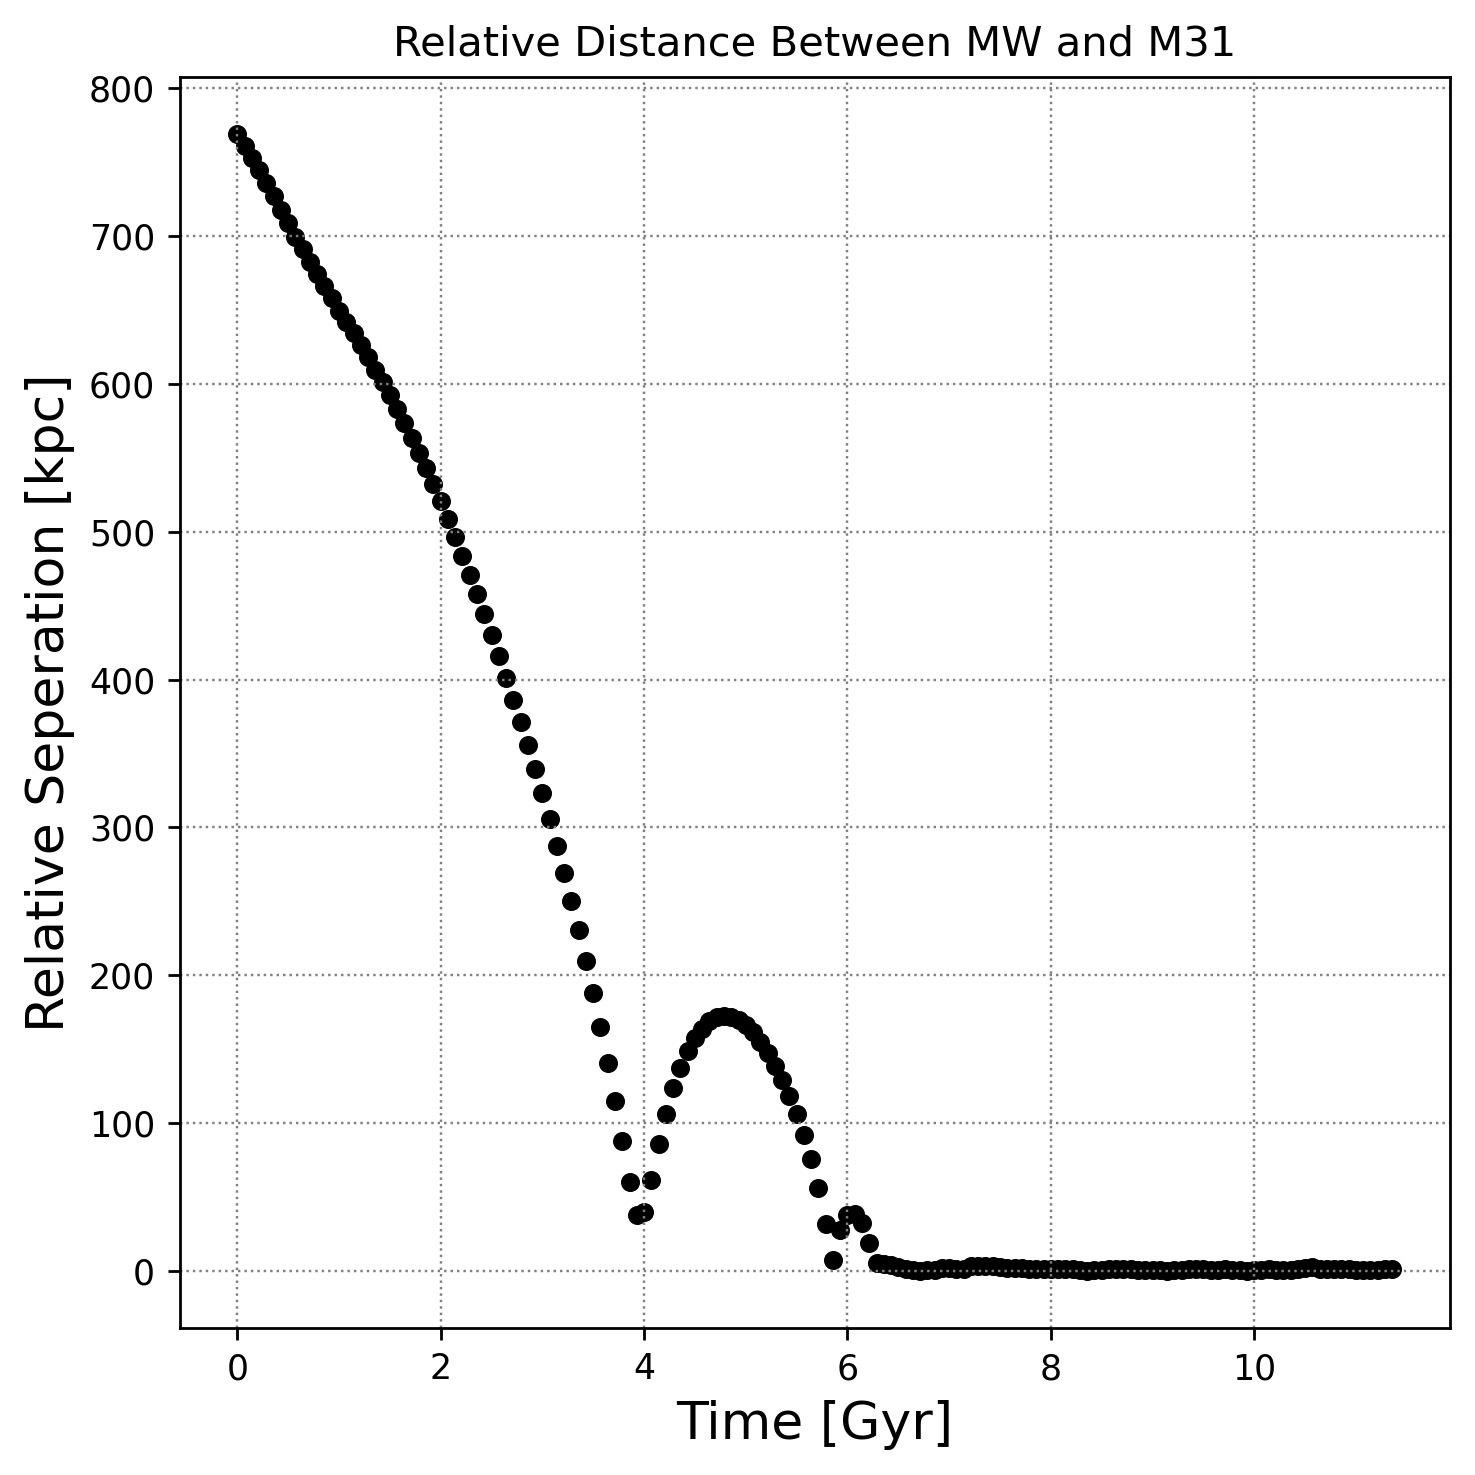

In [7]:
# Relative Seperation of MW and M31 #
PlotRelativeSeperation('Orbit_MW.txt', 'Orbit_M31.txt', 'Distance')

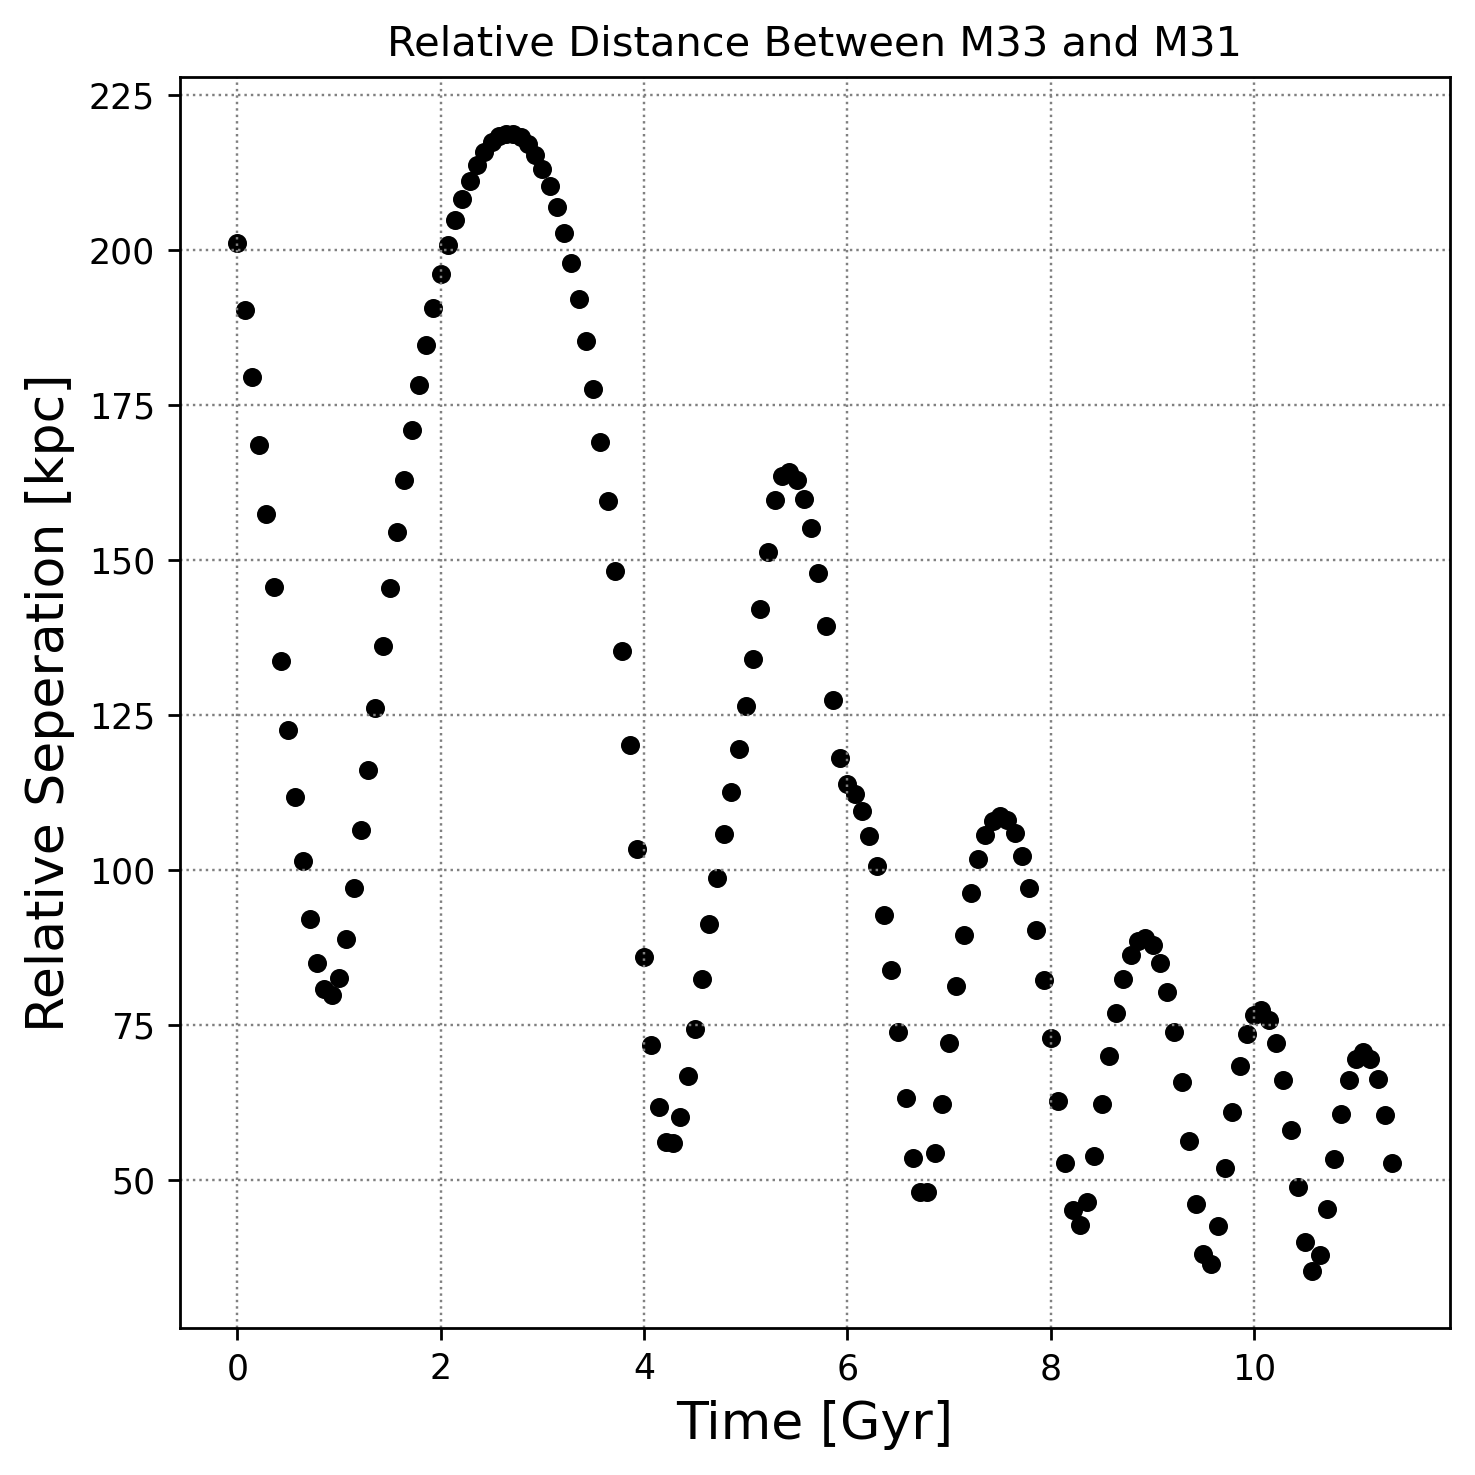

In [8]:
# Relative Seperation of M33 and M31 #
PlotRelativeSeperation('Orbit_M33.txt', 'Orbit_M31.txt', 'Distance')

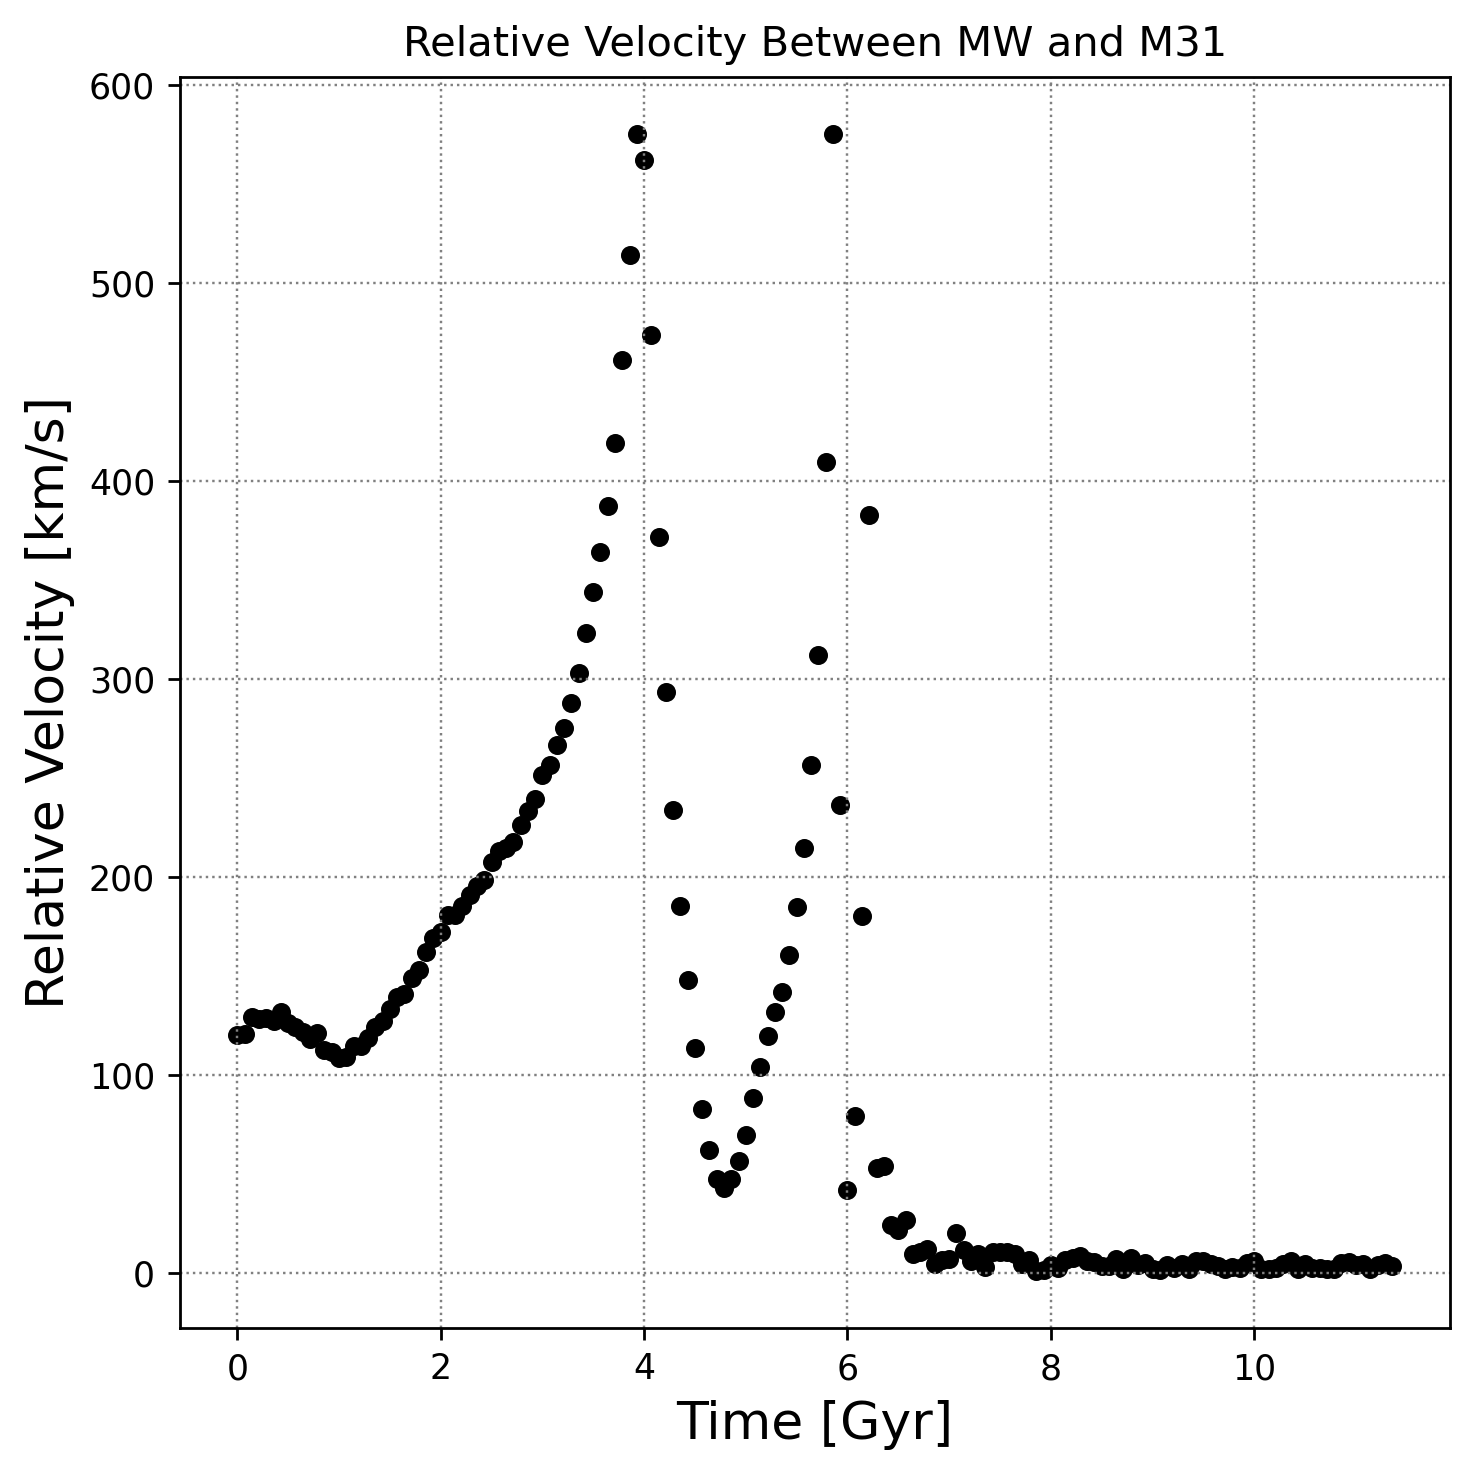

In [9]:
# Relative Velocity of MW and M31 #
PlotRelativeSeperation('Orbit_MW.txt', 'Orbit_M31.txt', 'Velocity')

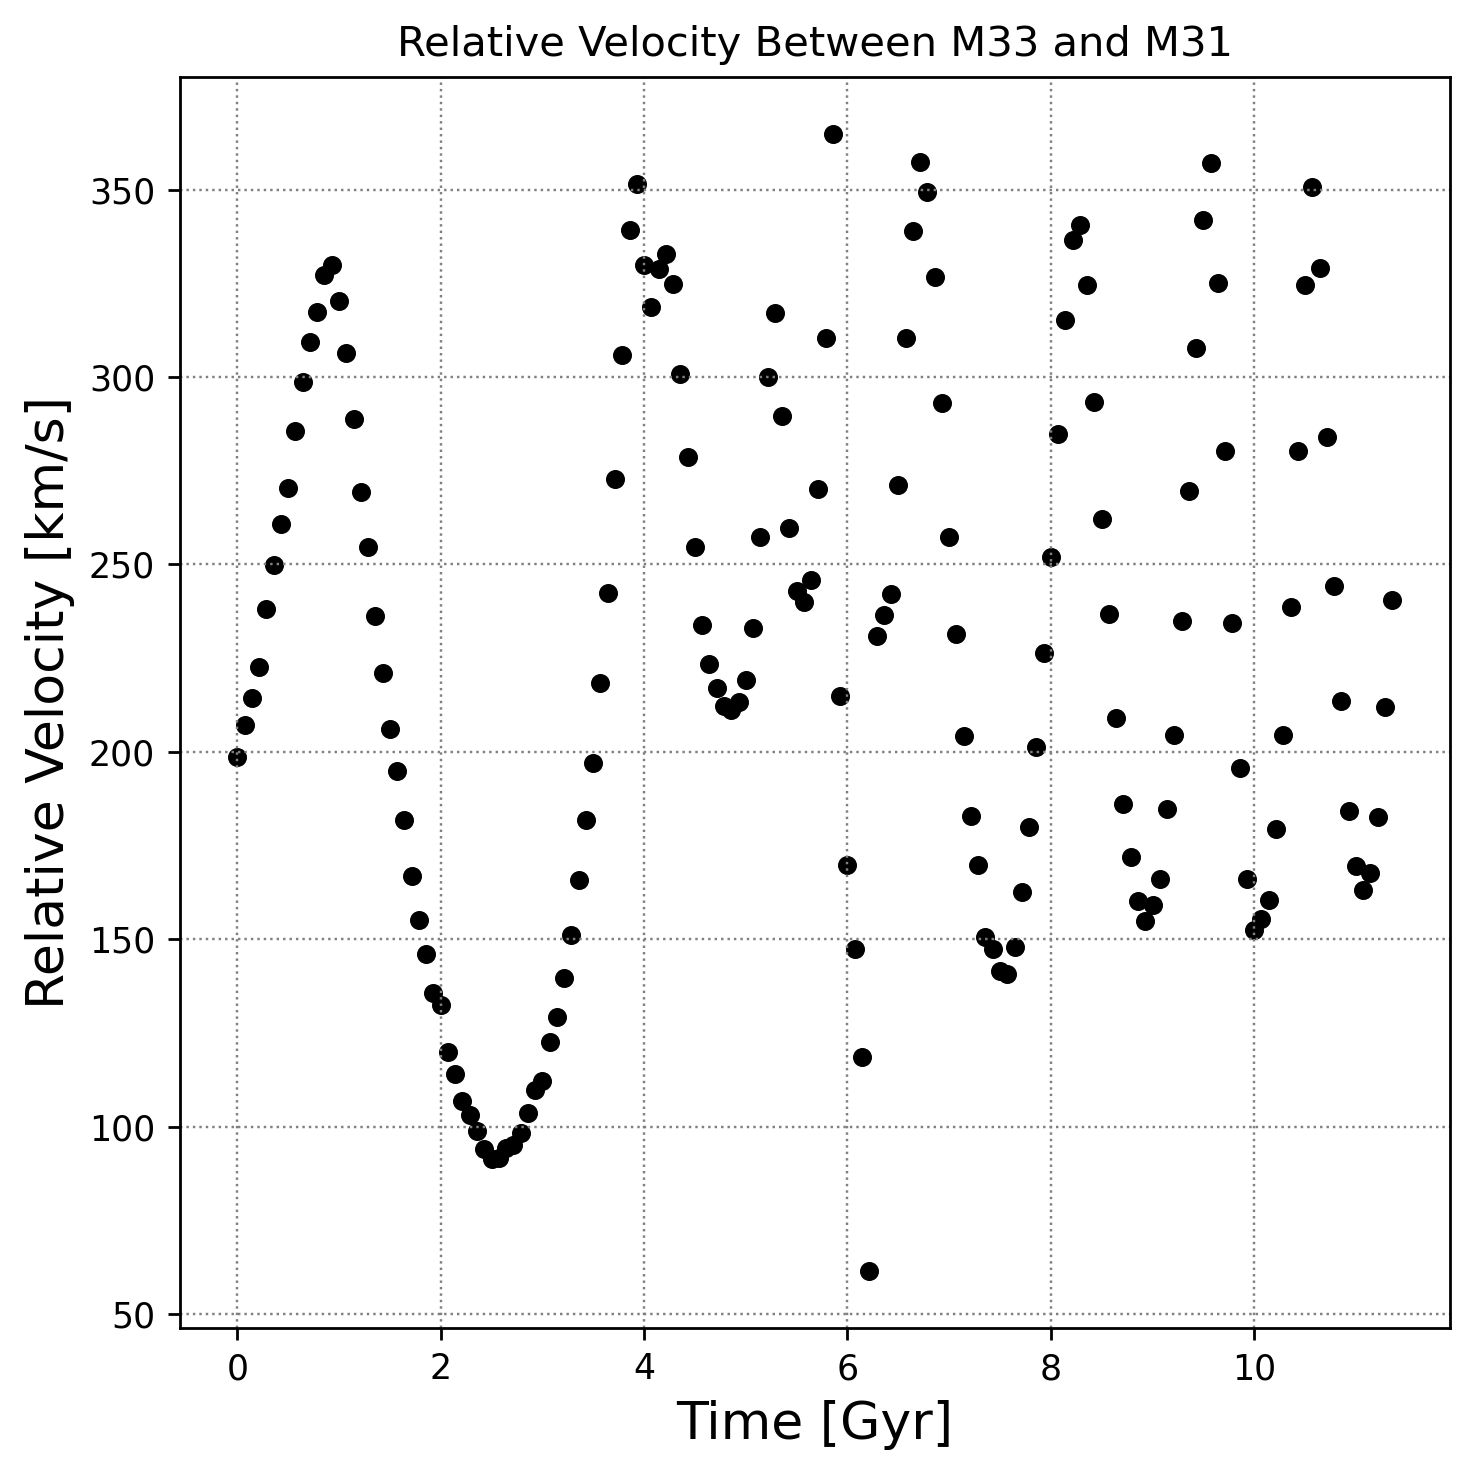

In [10]:
# Relative Velocity of M33 and M31 #
PlotRelativeSeperation('Orbit_M33.txt', 'Orbit_M31.txt', 'Velocity')

# Part 4: Questions #

1) The MW and M31 will expierence 2 close encounters before merging at the third encounter. 

2) The relationship appears to be inverse as we can see clearly with the M31 and M33 system. 

3) The systems merge at around ~6.7 Gyrs. M33's orbit begins decaying much more rapidly than before, which is likely due to the increased mass of the host body it is orbiting dragging it inward. 

4) Using the 2 points directly after 6Gyr I have (rough estimatations):

(88kpc - 110 kpc) / (8.8 Gyr - 7.5 Gyr) = 16.9 kpc / Gyr

At a distance of around 75 kpc, M33 will likley have merged with MW + M31 in about 4.44 Gyrs. 
